## To Look Into Correlation of DL USI 66.7ms

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from scipy import stats

ul_num_reliable_df = pd.read_csv("/media/research-student/KingstonSSD/FANET_Dataset/DJISpark_Measured_Throughput_100000_Samples/data_manual_throughput_uav_interference/uav_scenario_0_ul_processed.csv")

usi_667 = ul_num_reliable_df.loc[(ul_num_reliable_df["USI"]==66.7)&(ul_num_reliable_df["Time"]>=1)]
usi_100 = ul_num_reliable_df.loc[(ul_num_reliable_df["USI"]==100)&(ul_num_reliable_df["Time"]>=1)]

In [32]:
spearmanr_ul_usi_667 = stats.spearmanr(usi_667["Num_Reliable"].values, usi_667["Measured_Reliability_1"].values)
print(spearmanr_ul_usi_667.correlation)

# Try with drop duplicates
usi_667_uniq = usi_667.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
spearmanr_ul_usi_667 = stats.spearmanr(usi_667_uniq["Num_Reliable"].values, usi_667_uniq["Measured_Reliability_1"].values)
print(spearmanr_ul_usi_667.correlation)

0.29095569029363133
0.9860885987353964


In [33]:
spearmanr_ul_usi_100 = stats.spearmanr(usi_100["Num_Reliable"].values, usi_100["Measured_Reliability_1"].values)
print(spearmanr_ul_usi_100.correlation)

# Try with drop duplicates
usi_100_uniq = usi_100.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
spearmanr_ul_usi_100 = stats.spearmanr(usi_100_uniq["Num_Reliable"].values, usi_100_uniq["Measured_Reliability_1"].values)
print(spearmanr_ul_usi_100.correlation)

0.9207021445685923
0.9680834393492468


In [8]:
kendallt_ul_usi_667 = stats.kendalltau(usi_667["Num_Reliable"].values, usi_667["Measured_Reliability_1"].values, variant='b')
print(kendallt_ul_usi_667.correlation)

# Try with drop duplicates
usi_667_uniq = usi_667.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
kendallt_ul_usi_667 = stats.kendalltau(usi_667_uniq["Num_Reliable"].values, usi_667_uniq["Measured_Reliability_1"].values, variant='b')
print(kendallt_ul_usi_667.correlation)

0.28733951795539175
0.9056609913424054


In [27]:
weightedt_ul_usi_667 = stats.weightedtau(usi_667["Num_Reliable"].values, usi_667["Measured_Reliability_1"].values)
print(weightedt_ul_usi_667.correlation)

0.02034745312308754


In [6]:
kendallt_ul_usi_100 = stats.kendalltau(usi_100["Num_Reliable"].values, usi_100["Measured_Reliability_1"].values, variant='b')
print(kendallt_ul_usi_100.correlation)

# Try with drop duplicates
usi_100_uniq = usi_100.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
kendallt_ul_usi_100 = stats.kendalltau(usi_100_uniq["Num_Reliable"].values, usi_100_uniq["Measured_Reliability_1"].values, variant='b')
print(kendallt_ul_usi_100.correlation)

0.9204783321596677
0.8626950212987622


/home/research-student/.local/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4868: RuntimeWarning: overflow encountered in long_scalars
  (2 * xtie * ytie) / m + x0 * y0 / (9 * m * (size - 2)))


Text(0.5, 0, '$\\gamma$')

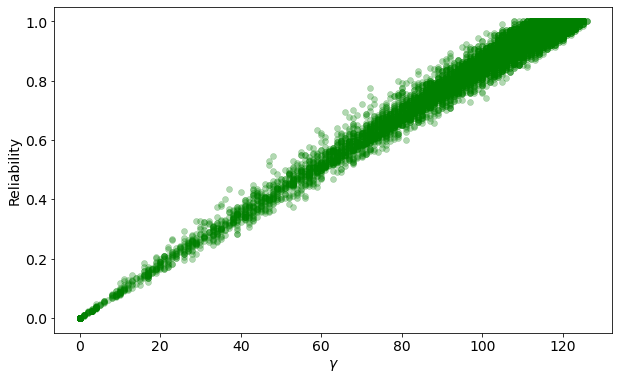

In [35]:
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(usi_667["Num_Reliable"], usi_667["Measured_Reliability_1"], c="g", alpha=0.3, linewidths=0.5)
plt.ylabel("Reliability")
plt.xlabel("$\\gamma$")

In [ ]:
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(usi_667_uniq["Num_Reliable"], usi_667_uniq["Measured_Reliability_1"], c="g", alpha=0.5, linewidths=0.5)
plt.ylabel("Reliability")
plt.xlabel("$\\gamma$")

Text(0.5, 0, '$\\gamma$')

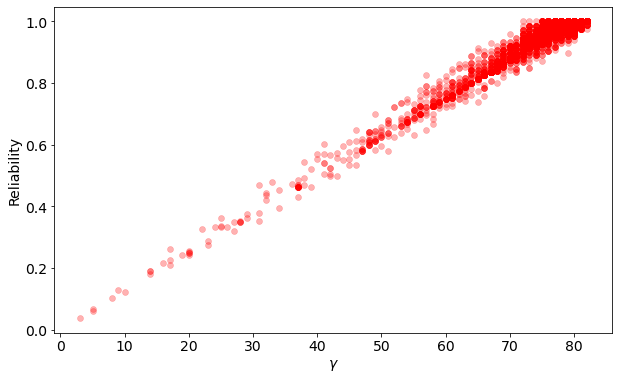

In [38]:
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(usi_100["Num_Reliable"], usi_100["Measured_Reliability_1"], c="r", alpha=0.3, linewidths=0.5)
plt.ylabel("Reliability")
plt.xlabel("$\\gamma$")

In [37]:
usi_667_uniq = usi_667.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])
usi_100_uniq = usi_100.drop_duplicates(subset=["Num_Reliable", "Measured_Reliability_1"])

percent_dup_667 = 100 - len(usi_667_uniq)/len(usi_667) * 100
percent_dup_100 = 100 - len(usi_100_uniq)/len(usi_100) * 100
print(percent_dup_667, percent_dup_100)

99.96682280159081 99.99336661911555


In [39]:
print(len(usi_667), len(usi_100))

5657500 5608000


## Custom Data Investigation

0.9612676056338026 0.90625


Text(0.5, 0, 'x')

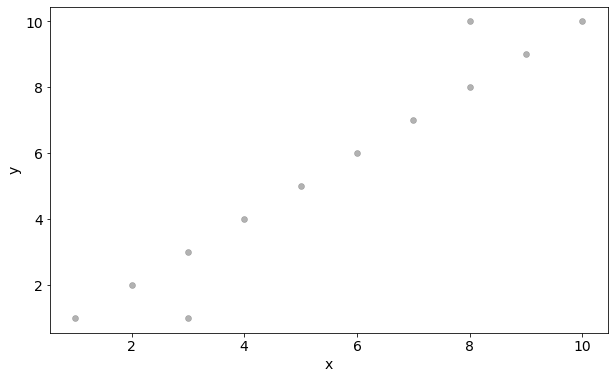

In [17]:
#Custom data investigation
x1 = [1,2,3,3,4,5,6,7,8,8,9,10]
y1 = [1,2,3,1,4,5,6,7,8,10,9,10]
spearmanr_1 = stats.spearmanr(x1,y1)
kendallt_1 = stats.kendalltau(x1,y1,variant='b')
print(spearmanr_1.correlation, kendallt_1.correlation)
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(x1, y1, c="k", alpha=0.3, linewidths=0.5)
plt.ylabel("y")
plt.xlabel("x")

0.9021739130434785 0.8269230769230771 0.8899946059960825


Text(0.5, 0, 'x')

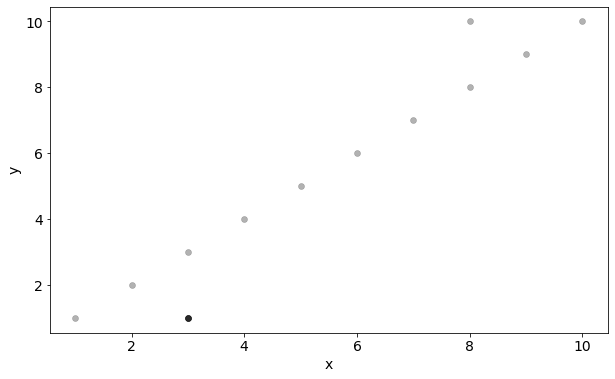

In [31]:
x2 = [1,2,3,3,3,3,3,3,4,5,6,7,8,8,9,10]
y2 = [1,2,3,1,1,1,1,1,4,5,6,7,8,10,9,10]
spearmanr_2 = stats.spearmanr(x2,y2)
kendallt_2 = stats.kendalltau(x2,y2,variant='b')
weightt_2 = stats.weightedtau(x2,y2)
print(spearmanr_2.correlation, kendallt_2.correlation, weightt_2.correlation)
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(x2, y2, c="k", alpha=0.3, linewidths=0.5)
plt.ylabel("y")
plt.xlabel("x")

0.9021739130434785 0.8269230769230771 0.7538703991950956


Text(0.5, 0, 'x')

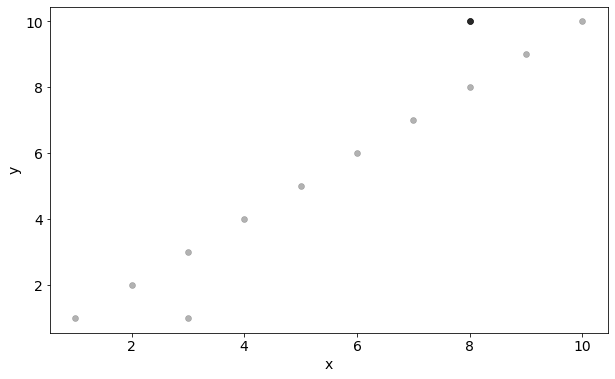

In [30]:
x3 = [1,2,3,3,4,5,6,7,8,8,8,8,8,8,9,10]
y3 = [1,2,3,1,4,5,6,7,8,10,10,10,10,10,9,10]
spearmanr_3 = stats.spearmanr(x3,y3)
kendallt_3 = stats.kendalltau(x3,y3,variant='b')
weightt_3 = stats.weightedtau(x3,y3)
print(spearmanr_3.correlation, kendallt_3.correlation, weightt_3.correlation)
plt.figure(figsize=(10,6))
plt.rcParams.update({'font.size': 14})
plt.scatter(x3, y3, c="k", alpha=0.3, linewidths=0.5)
plt.ylabel("y")
plt.xlabel("x")

In [ ]:
x = [12, 2, 1,12 , 2]
y = [1, 4, 7,1, 0]

kendallt = stats.kendalltau(x,y)
weightedt = stats.weightedtau(x,y)

print(kendallt, weightedt)

KendalltauResult(correlation=-0.7276068751089989, pvalue=0.04243806360030073) WeightedTauResult(correlation=-0.7655404856707593, pvalue=nan)
